# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [347]:
# importar librerías
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [348]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [349]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [350]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**
 - El dataset no tiene valores ausentes. Las 9 columnas tienen 40,000 valores no nulos cada una.
 - Tipos de dato:
     - La columna `date` es de tipo *object (texto)* y debería ser *datetime64*, ya que representa fechas. Esto es importante porque si la dejamos como texto no podríamos hacer operaciones de series de tiempo de forma confiable. Pero como ninguna operación del proyecto requiere hacer calculos con esta columna no hace falta cambiar el dtype de `date`. Es decir, no hacemos ninguna modificación.
     - El resto de tipos están correctos: `converted` como *int64* (binaria 0/1) y `gasto` como *float64* (numérica) están bien. Las columnas categóricas (`landing, region, dispositivo, traffic_source, user_type, user_id`) como *object* también es correcto para texto/categorías.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [351]:
#Cantidad de usuarios unicos
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [352]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [353]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [354]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [355]:
# Resumen estadístico de usuarios que se convirtieron
df_convertidos = df[df['converted'] == 1]
df_convertidos['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [356]:
# Explorar variables categóricas y cómo se distribuyen
columnas_categoricas = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

print("\nConteo de categorías:")
for col in columnas_categoricas:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()    


Conteo de categorías:
--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64



✍️ **Comentario**
- Todas las columnas tienen valores esperados. No hay errores de categorías mal escritas ni valores fuera de lo esperado:
    - `landing`: solo A y B ✔️
    - `region`: solo Norte, Centro, Sur, Occidente, Oriente (5 categorías, sin duplicados por errores de escritura como "norte" en minúscula) ✔️
    - `dispositivo`: solo Mobile y Desktop ✔️
    - `traffic_source`: solo Organic, Ads, Email, Referral ✔️
    - `user_type`: solo Nuevo y Recurrente ✔️
    - `converted`: solo 0 y 1 (binaria, como se esperaba) ✔️
    - `gasto`: mínimo es 0.0, sin valores negativos ✔️

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [357]:
# Gasto por versión
gasto_A = df_convertidos[df_convertidos['landing'] == 'A']['gasto']
gasto_B = df_convertidos[df_convertidos['landing'] == 'B']['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba de significancia estadística (t-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay diferencia en el gasto promedio entre A y B (media_A = media_B).
- **Hipótesis alternativa (H₁):** Sí hay diferencia en el gasto promedio entre A y B (media_A ≠ media_B)

In [358]:
# Verificar supuestos
var_A = gasto_A.var()
var_B = gasto_B.var()

print(f'Varianza A: {var_A:.2f}')
print(f'Varianza B: {var_B:.2f}')
print(f'Razón de varianzas (mayor/menor): {max(var_A, var_B) / min(var_A, var_B):.2f}')

Varianza A: 833.79
Varianza B: 1024.07
Razón de varianzas (mayor/menor): 1.23


**Verificar supuestos - justificación**
- La razón de varianzas (1.23) es menor a 2, lo cual indica que las varianzas de A y B son bastante similares. Por lo tanto, que usamos equal_var=True.

In [359]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=True)

# Visualizar resultados
print(f'Estadístico t: {t_stat:.5f}')
print(f'Valor p: {p_value:.5f}')

Estadístico t: -9.36564
Valor p: 0.00000


In [360]:
# Interpretación de p_value
alpha = 0.05
if p_value < alpha:
    print('Rechazamos H0: hay una diferencia estadísticamente significativa en el gasto promedio entre A y B')
else:
    print('No rechazamos H0: no hay evidencia suficiente de diferencia en el gasto promedio')

Rechazamos H0: hay una diferencia estadísticamente significativa en el gasto promedio entre A y B


### 📝 Conclusión e interpretación

**Decisión:**  
- Con un valor p < 0.0001, muy por debajo del nivel de significancia habitual (α = 0.05), se rechaza la hipótesis nula (H0). Existe evidencia estadística suficiente para afirmar que el gasto promedio de los usuarios convertidos sí difiere entre la página A y la página B.

**Interpretación de negocio:**  
- El t-test muestra que la diferencia en el gasto promedio entre la página A y la página B es estadísticamente significativa (p < 0.0001), es decir, no se explica por azar. Esto indica que la versión de la página sí influye en cuánto gastan los usuarios una vez que deciden convertir, y que la página B tiene un efecto real en generar mayor valor económico por cliente en comparación con la página A.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba de diferencia de proporciones (z-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay diferencia en la tasa de conversión entre la página A y la página B (tasa_conversión_A = tasa_conversión_B). Es decir, la versión de la página no influye en si un usuario convierte o no.
- **Hipótesis alternativa (H₁):** Sí hay diferencia en la tasa de conversión entre la página A y la página B (tasa_conversión_A ≠ tasa_conversión_B). Es decir, la versión de la página sí influye en la probabilidad de conversión.

In [361]:
# Número de usuarios convertidos por página
convertidos_por_pagina = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_por_pagina = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", convertidos_por_pagina)
print("\nTotal de usuarios por página:\n", total_por_pagina)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [362]:
# Pasar datos a formato lista
conteos = [convertidos_por_pagina['B'], convertidos_por_pagina['A']]
num_observaciones = [total_por_pagina['B'], total_por_pagina['A']]

print(conteos)
print(num_observaciones)

[3194, 2512]
[20018, 19982]


In [363]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(conteos, num_observaciones)


# Visualizar resultados
print(f"Estadístico: {z_stat:.4f}")
print(f"Valor p: {p_value:.6f}")

Estadístico: 9.6774
Valor p: 0.000000


In [364]:
# Interpretación de p_value
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de diferencia en la tasa de conversión entre la página A y la página B.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia en la tasa de conversión entre la página A y la página B.")

Rechazamos la hipótesis nula: hay evidencia de diferencia en la tasa de conversión entre la página A y la página B.


### 📝 Conclusión e interpretación

**Decisión:**  
Con un valor p < 0.000001, muy por debajo del nivel de significancia de 0.05, se rechaza la hipótesis nula (H0). Existe evidencia estadística suficiente para afirmar que la tasa de conversión entre la página A y la página B es diferente.

**Interpretación de negocio:**  
El z-test confirma que la diferencia en la tasa de conversión entre la página A y la página B es estadísticamente significativa, no producto del azar. Esto indica que la versión de la página sí influye en la probabilidad de que un usuario convierta, y que la página B es más efectiva que la página A en lograr conversiones.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre la fuente de tráfico (`traffic_source`) y la conversión (`converted`). Es decir, la probabilidad de convertir es independiente del canal por el que llegó el usuario.
- **Hipótesis alternativa (H₁):** Sí existe asociación entre la fuente de tráfico (`traffic_source`) y la conversión (`converted`). Es decir, la probabilidad de convertir depende del canal por el que llegó el usuario.

In [365]:
# Construir tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [366]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}") 


Estadístico chi-cuadrado: 8.662
Valor P: 0.034


In [367]:
#Verificar supuestos - justificación
print(f'Frecuencia esperada mínima: {expected.min():.2f}')

if expected.min() >= 5:
    print('Se cumple el supuesto: la frecuencia esperadas es >= 5')
else:
    print('No se cumple el supuesto: hay al menos una celda con frecuencia esperada < 5')

Frecuencia esperada mínima: 564.18
Se cumple el supuesto: la frecuencia esperadas es >= 5


In [368]:
# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


In [369]:
# Tabla de contingencia normalizada
print(pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100)

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Con un valor p = 0.034, por debajo del nivel de significancia de 0.05, se rechaza la hipótesis nula (H0). Existe evidencia estadística de que la conversión no es independiente de la fuente de tráfico.

**Interpretación de negocio:**  
La prueba de chi-cuadrado muestra que sí existe una asociación estadísticamente significativa entre el canal por el que llega el usuario y su probabilidad de convertir. Esto indica que el canal de adquisición influye en la conversión, por lo que no todos los canales de tráfico tienen el mismo desempeño y conviene tenerlos en cuenta al momento de decidir dónde invertir en adquisición de usuarios.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba de chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre el tipo de usuario (`user_type`) y la conversión (`converted`). Es decir, la probabilidad de convertir es independiente de si el usuario es nuevo o recurrente.
- **Hipótesis alternativa (H₁):** Sí existe asociación entre el tipo de usuario (`user_type`) y la conversión (`converted`). Es decir, la probabilidad de convertir depende de si el usuario es nuevo o recurrente.

In [370]:
# Construir tabla de contingencia
tabla_user_type = pd.crosstab(df['user_type'], df['converted'])
print(tabla_user_type)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [371]:
# Aplicar prueba
# Ejecutar prueba chi-cuadrada
chi2_stat_user_type, p_value_user_type, dof_user_type, expected_user_type = chi2_contingency(tabla_user_type)
print(f"\nEstadístico chi-cuadrado: {chi2_stat_user_type:.3f}")
print(f"Valor P: {p_value_user_type:.3f}")



Estadístico chi-cuadrado: 0.513
Valor P: 0.474


In [372]:
#Verificar supuestos - justificación
print(f'Frecuencia esperada mínima: {expected_user_type.min():.2f}')

if expected_user_type.min() >= 5:
    print('Se cumple el supuesto: la frecuencia esperadas es >= 5')
else:
    print('No se cumple el supuesto: hay al menos una celda con frecuencia esperada < 5')

Frecuencia esperada mínima: 1992.39
Se cumple el supuesto: la frecuencia esperadas es >= 5


In [373]:
# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value_user_type < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


In [374]:
# Tabla de contingencia normalizada
print(pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100)

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


### 📝 Conclusión e interpretación

**Decisión:**  
Con un valor p = 0.474, muy por encima del nivel de significancia de 0.05, no se rechaza la hipótesis nula (H0). No hay evidencia estadística suficiente para afirmar que exista asociación entre el tipo de usuario ('user_type') y la conversión ('converted').

**Interpretación de negocio:**  
La prueba de chi-cuadrado indica que no existe una asociación estadísticamente significativa entre el tipo de usuario (nuevo o recurrente) y la probabilidad de convertir. Esto sugiere que, en este experimento, el hecho de ser un usuario nuevo o uno que ya había visitado antes no influye en la decisión de conversión, por lo que no habría una base estadística para segmentar la estrategia según este criterio.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

---

### Relación entre la fuente de tráfico y la conversión

Text(0.5, 1.0, 'Conversiones por fuente de tráfico')

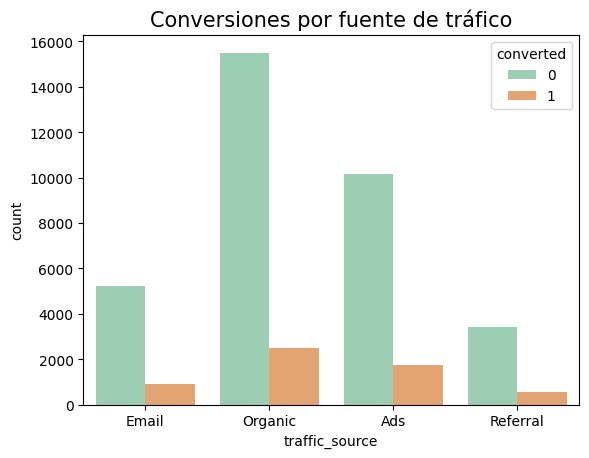

In [375]:
# Gráfico de barras agrupadas
sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por fuente de tráfico', fontsize=15)

✍️ **Comentario**: 

El gráfico de barras agrupadas muestra, para cada fuente de tráfico, la cantidad absoluta de usuarios que convirtieron (1) frente a los que no convirtieron (0). Se observa que Organic concentra el mayor volumen de usuarios en ambas categorías, ya que es el canal con más tráfico total, seguido de Ads, Email y Referral. Es importante notar que este gráfico refleja el tamaño de cada canal en términos de usuarios, pero no permite comparar directamente qué tan bien convierte cada uno, ya que canales con más tráfico naturalmente tendrán más conversiones en números absolutos aunque su efectividad relativa sea menor.

In [ ]:
# Gráfico de barras apiladas (tabla normalizada, ya que en el Paso 4 no la guardamos como variable)
tabla_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_normalizada.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)

✍️ **Comentario**:

El gráfico de barras apiladas complementa al anterior mostrando la proporción (%) de usuarios convertidos y no convertidos dentro de cada canal, normalizando cada barra al 100%. Esto permite comparar la efectividad relativa de cada fuente de tráfico sin que el volumen total distorsione la lectura. Aquí se aprecia que, aunque las diferencias entre canales son visualmente pequeñas, Email y Ads muestran una proporción ligeramente mayor de conversión respecto a Organic y Referral, lo cual es consistente con el resultado significativo obtenido en la prueba de chi-cuadrado del Paso 4.

---

### Relación entre el tipo de usuario y la conversión

In [ ]:
# Gráfico de barras agrupadas
sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por tipo de usuario', fontsize=15)

✍️ **Comentario**:

El gráfico de barras agrupadas muestra, para cada tipo de usuario, la cantidad absoluta de conversiones (1) y no conversiones (0). Se observa que Nuevo concentra un volumen considerablemente mayor de usuarios en ambas categorías, simplemente porque este grupo es casi el doble de grande que Recurrente en la base de datos. Al igual que con la fuente de tráfico, este gráfico refleja el tamaño de cada segmento y no permite, por sí solo, comparar qué tan efectivo es cada tipo de usuario para convertir.

In [ ]:
# Gráfico de barras apiladas
tabla_normalizada_user_type = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_normalizada_user_type.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por tipo de usuario', fontsize=15)

✍️ **Comentario**

El gráfico de barras apiladas muestra la proporción (%) de conversión dentro de cada tipo de usuario, normalizando cada barra al 100%. A diferencia del gráfico anterior, aquí se elimina el efecto del tamaño de cada grupo y se puede comparar la efectividad relativa directamente. Se observa que las proporciones de conversión entre Nuevo y Recurrente son prácticamente idénticas, lo cual es consistente con el resultado no significativo (p = 0.474) obtenido en la prueba de chi-cuadrado del Paso 5: el tipo de usuario no parece influir en la probabilidad de convertir.

---

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

---

**Preguntas a responder:**  
- **¿Qué página genera mayor conversión y gasto promedio?**
    - La página B es superior en ambas métricas. Convierte al 15.96% de sus usuarios frente a 12.57% en A (diferencia estadísticamente significativa, p < 0.000001), y entre los usuarios que compran, gastan en promedio $$68.75 en B frente a $61.09 en A, un 12.5% más (también significativo, p < 0.0001). B genera más valor económico tanto por mayor volumen de conversiones como por mayor gasto por cliente.
- **¿Qué canales de tráfico son más efectivos para generar conversiones?**
    - Existe una asociación estadísticamente significativa entre el canal y la conversión (p = 0.034), aunque las diferencias son moderadas. Email (14.99%) y Ads (14.74%) tienen las tasas de conversión más altas, mientras que Referral (13.88%) y Organic (13.79%) son las más bajas. Sin embargo, en volumen absoluto, Organic sigue siendo el canal que más conversiones aporta al negocio, simplemente por ser el de mayor tráfico total.
- **¿Existen diferencias significativas según el tipo de usuario?**
    - No. La prueba de chi-cuadrado no encontró asociación estadísticamente significativa entre el tipo de usuario y la conversión (p = 0.474). Usuarios Nuevos (14.36%) y Recurrentes (14.09%) convierten a tasas prácticamente idénticas, por lo que este criterio no es útil para segmentar la estrategia.
- **¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?**
    -  Migrar el tráfico a la página B como versión predeterminada, dado su desempeño superior tanto en conversión como en gasto promedio.
    -  Priorizar inversión en Email y Ads, los canales con mejor tasa de conversión, y revisar por qué Organic y Referral convierten menos (aunque Organic sigue siendo clave por su volumen).
    -  No segmentar la estrategia por tipo de usuario (nuevo vs. recurrente), ya que no hay evidencia de que este factor influya en la conversión — los recursos son mejor invertidos en otras variables (página y canal).

---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

- **Gasto promedio por usuario que convirtió:**
    - La página B registró un gasto promedio de $$68.75 por usuario convertido, frente a $61.09 en la página A.
    - La diferencia ($7.66, equivalente a 12.5% más) es estadísticamente significativa (t-test de Welch, p < 0.0001).
- **Interpretación:**
    - Los usuarios que compran en B no solo son más numerosos, sino que también gastan más por transacción, lo que indica que B genera un mayor valor económico por cliente convertido.

<br>

- **Tasa de conversión:** 
    - La página B alcanzó una tasa de conversión de 15.96%, frente a 12.57% en la página A.
    - La diferencia (3.38 puntos porcentuales, un 26.9% más en términos relativos) es estadísticamente significativa (z-test de proporciones, p < 0.000001).
- **Interpretación:**
    - la página B es significativamente más efectiva logrando que los usuarios conviertan, lo que confirma que su mejor desempeño no se limita al gasto, sino que también capta una mayor proporción de compradores.

---

#### 📊 **Segmentación por fuente de tráfico**
- **Observación:**
    - Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (chi-cuadrado, p = 0.034), con tasas de conversión de 14.99% en Email, 14.74% en Ads, 13.88% en Referral y 13.79% en Organic; sin embargo, Organic es el canal que más volumen absoluto de conversiones aporta por ser la fuente con mayor tráfico total.
- **Interpretación:**
    - El canal de adquisición influye en la conversión, aunque las diferencias son moderadas — Email y Ads convierten proporcionalmente mejor, mientras que Organic sigue siendo clave por su volumen, lo que sugiere una oportunidad de optimización en la mezcla de canales más que un cambio radical de estrategia.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- **Observación:**
    - No se encontró asociación estadísticamente significativa entre el tipo de usuario y la conversión (chi-cuadrado, p = 0.474), con tasas prácticamente iguales entre usuarios Nuevos (14.36%) y Recurrentes (14.09%).
- **Interpretación:**
    - El tipo de usuario no es un factor relevante para explicar la conversión en este experimento, por lo que no se justifica diseñar una estrategia diferenciada según si el usuario es nuevo o recurrente.

---

**Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.**

---

#### 💡 **Recomendaciones de negocio:** 
- **Recomendación 1: Migrar todo el tráfico a la página B como versión estándar.**
    - Los resultados del experimento muestran una superioridad consistente y estadísticamente significativa de la página B sobre la A en las dos métricas clave del negocio: la tasa de conversión (15.96% vs. 12.57%, p < 0.000001) y el gasto promedio por usuario convertido ($68.75 vs. $61.09, p < 0.0001). Esto significa que B no solo logra que más usuarios compren, sino que además esos compradores gastan más, lo que se traduce en un impacto compuesto sobre los ingresos totales del negocio. Dado que ambos resultados están respaldados por pruebas estadísticas robustas sobre una muestra grande y balanceada (cerca de 20,000 usuarios por grupo), se recomienda descontinuar la página A y adoptar B como la versión definitiva de la landing page.

<br>
 
-  **Recomendación 2: Redistribuir la inversión de marketing priorizando Email y Ads, sin descuidar Organic.**
    - La prueba de asociación entre fuente de tráfico y conversión fue significativa (p = 0.034), con Email (14.99%) y Ads (14.74%) mostrando las tasas de conversión más altas, frente a Referral (13.88%) y Organic (13.79%). Sin embargo, dado que esta asociación es más débil que la observada en la comparación de páginas, y que Organic sigue aportando el mayor volumen absoluto de conversiones por su alto tráfico, la recomendación no es abandonar ningún canal, sino aumentar gradualmente la inversión en Email y Ads —los de mejor conversión relativa— mientras se monitorea si esto mejora el retorno general, sin reducir el peso de Organic como principal fuente de volumen. Por otro lado, dado que el tipo de usuario (nuevo vs. recurrente) no mostró relación significativa con la conversión (p = 0.474), no se recomienda invertir recursos en diferenciar la estrategia de marketing según este criterio.  